In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw3-task2.ipynb")

# Homework 3 - Task 2: Tree-Based Methods
## Predicting Water Potability Using Decision Trees and Random Forests

---


### Dataset

Access to safe drinking water is a fundamental public health concern. This dataset contains physicochemical measurements for 3,276 water samples, each labeled as potable or non-potable.

| Feature | Description |
|---|---|
| `ph` | pH value of water (0–14 scale) |
| `Hardness` | Capacity to precipitate soap (mg/L) |
| `Solids` | Total dissolved solids (ppm) |
| `Chloramines` | Amount of chloramines (ppm) |
| `Sulfate` | Amount of sulfates dissolved (mg/L) |
| `Conductivity` | Electrical conductivity (μS/cm) |
| `Organic_carbon` | Amount of organic carbon (ppm) |
| `Trihalomethanes` | Amount of trihalomethanes (μg/L) |
| `Turbidity` | Measure of light-emitting property (NTU) |

#### Response Variable

| Column | Description |
|---|---|
| `Potability` | Binary flag — `1` if water is safe to drink, `0` otherwise |


 **Note:** Several features contain missing values (`ph`, `Sulfate`, `Trihalomethanes`). You will handle these in the preprocessing step.

 This dataset comes from Kaggle and can be found [here](https://www.kaggle.com/datasets/uom190346a/water-quality-and-potability).

### Setup: Load Libraries

Run the cell below to import all required packages.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



### Step 1: Load the Data

Read `water_potability.csv` into a DataFrame. Preview the first few rows and confirm its shape.

In [4]:
df = pd.read_csv('water_potability.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


### Step 2: Explore the Data

Before modeling, examine the distribution of your response variable and the number of NAs. Understanding both will guide preprocessing decisions.

In [12]:
# Missing values
na_counts = df['Potability'].isna().value_counts()
na_counts

Potability
False    3276
Name: count, dtype: int64

There are 3,276 rows with NA values for Potability.

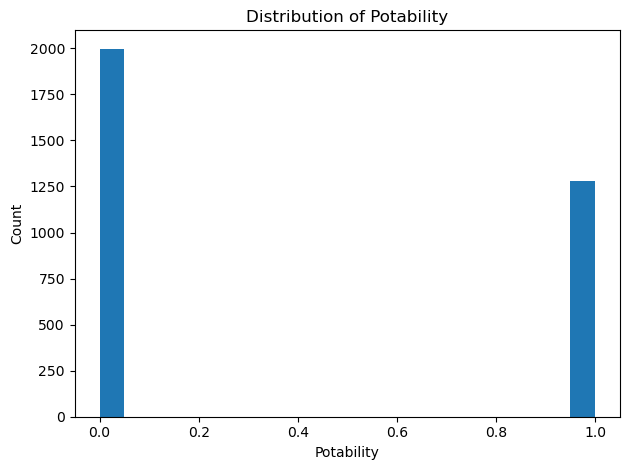

In [11]:
fig, ax = plt.subplots()

ax.hist(df['Potability'].dropna(), bins=20)
ax.set_title('Distribution of Potability')
ax.set_xlabel('Potability')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

Potability ranges between 0 and 1.

### Step 3: Preprocess the Data

Three features have missing values. A simple approach for tree-based methods is to **impute with the column median**. Impute the missing values using `df.fillna()`.Store your cleaned dataframe in a variable called `df_clean`. 

After imputation, split the data 70/30 into training and test sets, stratifying on `Potability` to preserve the class ratio in both splits.Store your results in `X_train`, `X_test`, `y_train`, and `y_test`.

In [15]:
# Impute NAs with median 
df_clean = df.fillna(df.median())
# Can also use .drop but I want to get familiar with the response variables
X = df_clean[['Hardness', 'Solids' ,'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 
              'Trihalomethanes', 'Turbidity']]
y = df_clean["Potability"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [23]:
df_clean = df.fillna(df.median())

X = df_clean.drop(columns = "Potability")
y = df_clean["Potability"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [24]:
grader.check("q1")

q1 results: All test cases passed!

### Step 4: Fit a Single Classification Tree

Start with an **unpruned** classification tree (no constraints on depth or leaf size). This gives a baseline and illustrates the overfitting problem that ensemble methods address.

Fit `DecisionTreeClassifier` with only `random_state=42` set (all other parameters at defaults). Report the tree depth in a variable named `tree_depth`. Calculate both the train accuracy and the test accuracy, storing the train accuracy in a variable called`dt_unpruned_acc_train` and the test accuracy in a variable called `dt_unpruned_acc_test`. 

In [25]:
dt_unpruned = DecisionTreeClassifier(random_state=42)
dt_unpruned.fit(X_train, y_train)

tree_depth = dt_unpruned.get_depth()
dt_unpruned_acc_train = accuracy_score(y_train, dt_unpruned.predict(X_train))
dt_unpruned_acc_test = accuracy_score(y_test, dt_unpruned.predict(X_test))
print(f"Unpruned Tree Depth: {tree_depth}")
print(f"Unpruned Tree Training Accuracy: {dt_unpruned_acc_train:.4f}")
print(f"Unpruned Tree Test Accuracy: {dt_unpruned_acc_test:.4f}")


Unpruned Tree Depth: 33
Unpruned Tree Training Accuracy: 1.0000
Unpruned Tree Test Accuracy: 0.5809


In [26]:
grader.check("q2")

q2 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q1: How does the training accuracy and test accuracy differ? What does this mean about your model?**

The training accuracy is greater than the test accuracy which is a clear sign that this model is overfitting. By having 33 depths, this model is predicting a singular point as itself which is why the accuracy is 1. 

<!-- END QUESTION -->

### Step 5: Tune Tree Depth with Cross-Validation

A fully grown tree memorizes the training data (better training accuracy, poor test accuracy). We need to find the right **depth** to prevent this. 

Using 5-fold cross-validation on the training set, compute mean CV accuracy for `max_depth` from 1 to 20. Identify the optimal depth using `np.argmax`, storing it in a variable called `optimal_depth`. Plot the CV Accuracy against the 20 different depths, adding a vertical line at the optimal depth. 

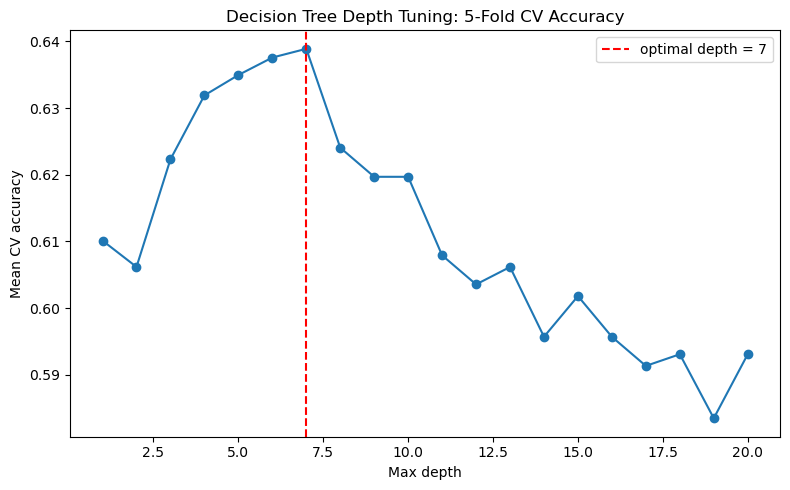

In [27]:
depths = range(1, 21)
cv_scores = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    scores = cross_val_score(dt, X_train, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

cv_scores = np.array(cv_scores)
optimal_depth = list(depths)[np.argmax(cv_scores)]

plt.figure(figsize=(8, 5))
plt.plot(depths, cv_scores, marker="o")
plt.axvline(optimal_depth, color="red", linestyle="--", label=f"optimal depth = {optimal_depth}")
plt.xlabel("Max depth")
plt.ylabel("Mean CV accuracy")
plt.title("Decision Tree Depth Tuning: 5-Fold CV Accuracy")
plt.legend()
plt.tight_layout()

In [28]:
grader.check("q3")

q3 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q2: What did cross fold validation find the optimal depth to be? Explain what these means in plain language.**

Through cross-validation, the model found the optimal depth to be 7. This means that the mazimum depths of the tree, over how many decisions the tree makes, only reaches to 7 levels or 7 splits in the data. 

<!-- END QUESTION -->

### Step 6: Fit the Tuned Decision Tree

Refit the decision tree using `optimal_depth` and evaluate on the held-out test set. Store the test accuracy in a variable called `acc_dt`. 

In [ ]:
dt_opt = DecisionTreeClassifier(max_depth=optimal_depth, random_state=42)
dt_opt.fit(X_train, y_train) # needs to be called dt_opt

acc_dt = accuracy_score(y_test, dt_opt.predict(X_test))
print(f"Optimally Pruned Tree Test Accuracy: {acc_dt:.4f}")

Optimally Pruned Tree Test Accuracy: 0.6460


In [39]:
grader.check("q4")

q4 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q3: Did the accuracy on your tuned decision tree imrpove compared to your untuned tree? If so, why do you think it improved?**

Yes, the accuracy on the tuned decision tree improved. The accuracy improved because it was allowed to split on the relationships that are most strong and generalizable across unseen data. 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 7: Visualize the Decision Tree

Plot the tuned tree using `plot_tree`. Save the tree as an image to evaluate the results and answer **Q5**. 

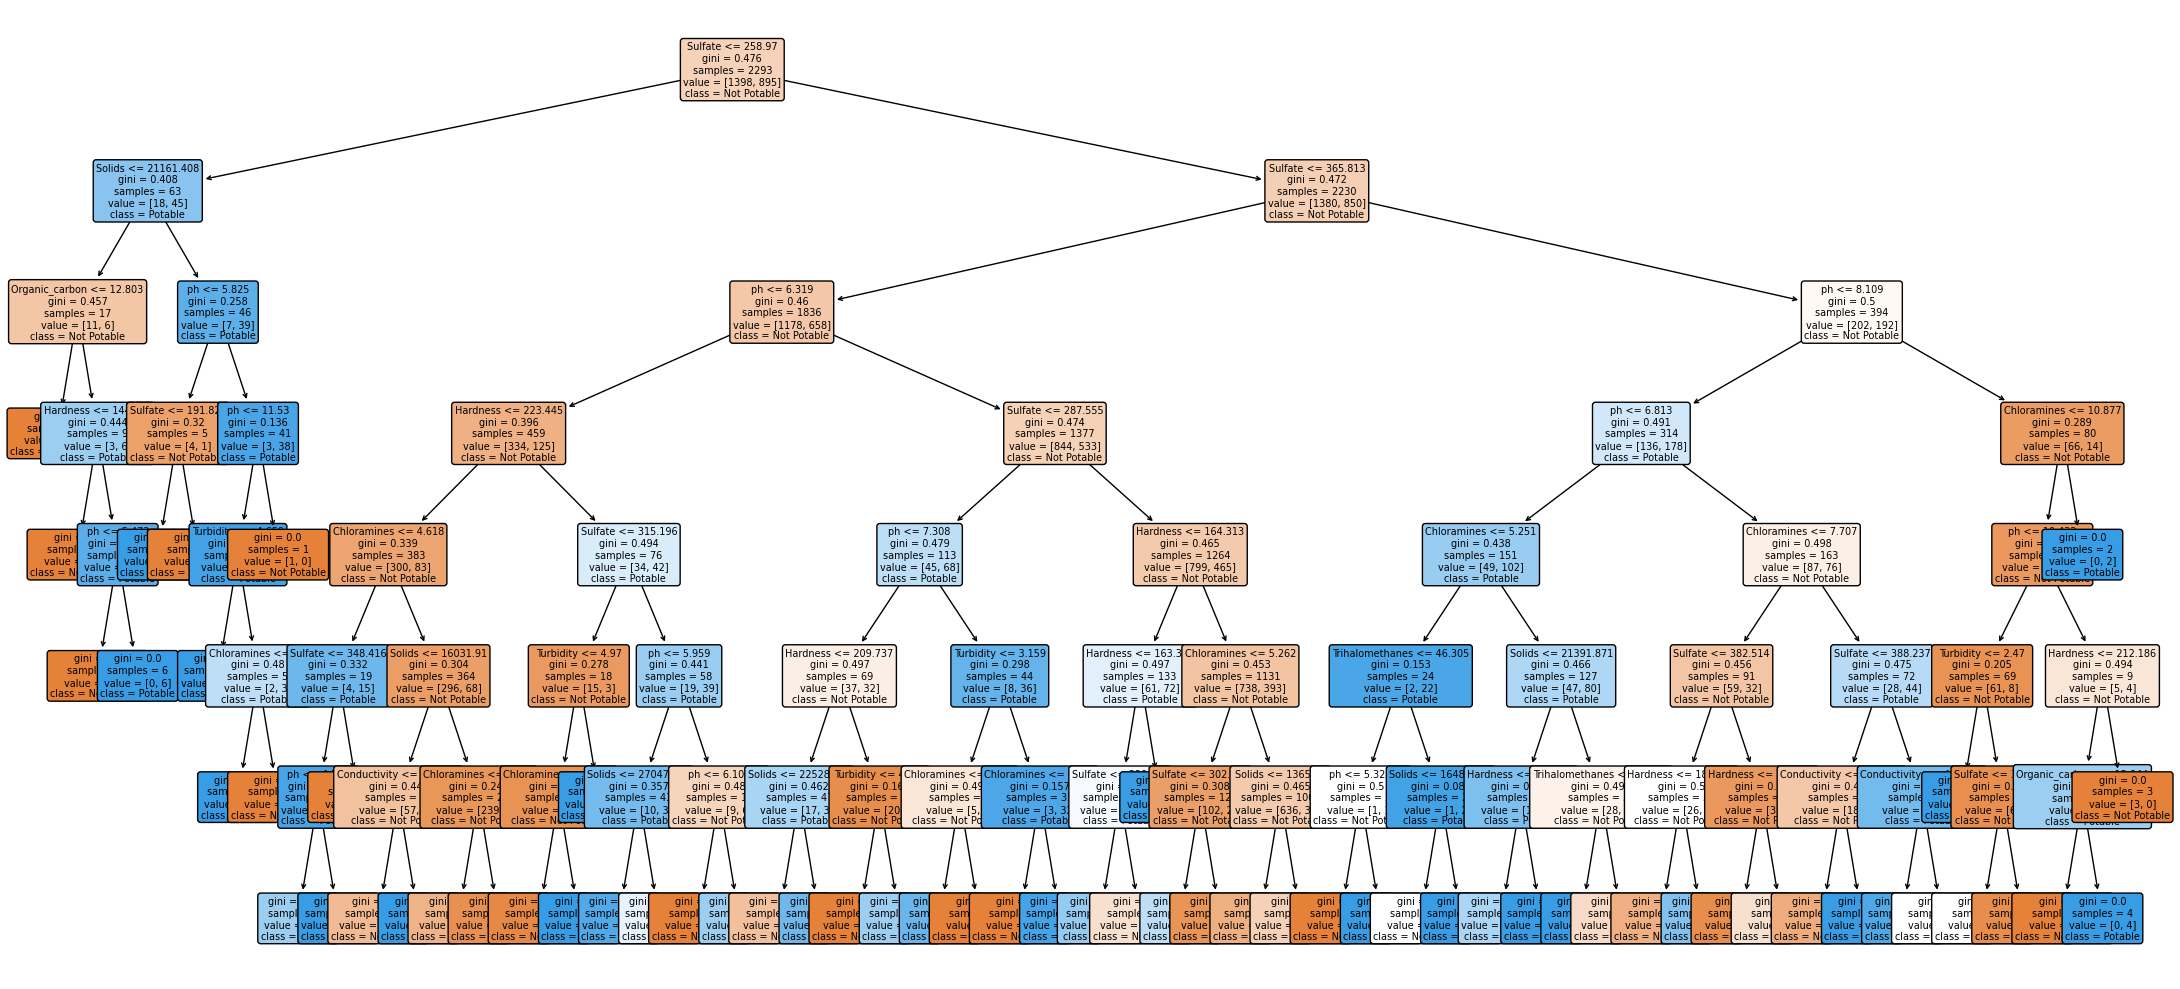

<Figure size 640x480 with 0 Axes>

In [41]:
plt.figure(figsize=(22, 10))
plot_tree(
    dt_opt,
    feature_names=X_train.columns, # Add feature names
    class_names=["Not Potable", "Potable"],
    filled=True,
    rounded=True,
    fontsize=7,
)
plt.tight_layout()
plt.show()
plt.savefig("tuned_tree.png", dpi=150)

> **Q4: Examine the root node and first two levels of the tree. Which feature is used for the root split, and what threshold does it use? What does this tell you about that feature's relationship with potability? What is the Gini impurity at the root, and how does it change after the first split?**

The first feature used in the first split is `sulfate` with a threshold used is <= 258. This tells us that sulfate is the most important feature. The gini impurity at the root is 0.476 which is close to 0 but results in gini impurities further down the trees that improve, a good sign that the model split the data well at the start. 

<!-- END QUESTION -->

### Step 8: Random Forest

**Random forests** address the high variance of a single tree by fitting many trees on bootstrap samples of the training data and averaging their predictions. To further reduce correlation among the trees, at each split only a random subset of $m$ features is considered (by default sklearn uses $m = \lfloor\sqrt{p}\rfloor$ for classification).

Fit a `RandomForestClassifier`, called `rf` with `n_estimators=200`. Report the accuracy and store it in `acc_rf`. 

In [42]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

acc_rf = accuracy_score(y_test, rf.predict(X_test))
print(f"Random Forest Test Accuracy: {acc_rf:.4f}")
print(f"Pruned Decision Tree Test Accuracy: {acc_dt:.4f}")

Random Forest Test Accuracy: 0.6612
Pruned Decision Tree Test Accuracy: 0.6460


In [43]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q5: Compare the test results of Decision Tree and Random Forest? Which performed beter? Why do you think this is?**

Random forest performed better than the original decision tree. This can be because the random forest reduced overfitting while also handling more variance in the data. 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 9: Feature Importances

Both decision trees and random forests assign an **importance score** to each feature based on the total reduction in impurity (Gini) it produces across all splits. Random forest importances are averaged over all trees in the ensemble, making them more stable than a single tree's importances.

Create a bar plot showing the feature importances from the tuned decision tree and the random forest side by side. You can access the feature importants from the model wtih `model.feature_importances_`.

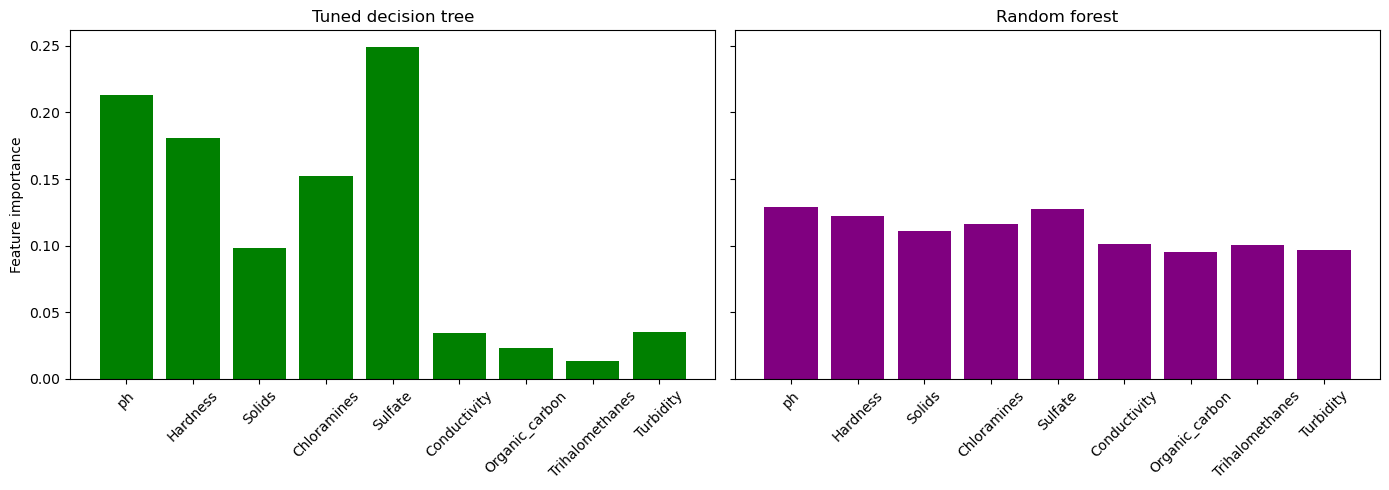

DT top: Sulfate
RF top: ph


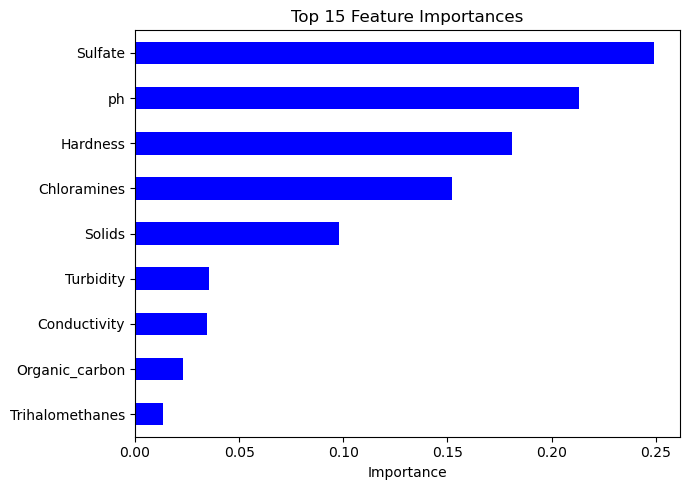

In [ ]:
feat = X_train.columns

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].bar(feat, dt_opt.feature_importances_, color="green")
axes[0].set_title("Tuned decision tree")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(feat, rf.feature_importances_, color="purple")
axes[1].set_title("Random forest")
axes[1].tick_params(axis="x", rotation=45)

axes[0].set_ylabel("Feature importance")
plt.tight_layout()
plt.show()

print("DT top:", feat[np.argmax(dt_opt.feature_importances_)])
print("RF top:", feat[np.argmax(rf.feature_importances_)])

# Optimal features according to dt (decision tree)
feat_imp = pd.Series(dt_opt.feature_importances_, index=feat).sort_values(ascending=False)

plt.figure(figsize=(7, 5))
feat_imp.head(15).sort_values().plot(kind='barh', color='blue')
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()


> **Q6: Do the decision tree and random forest agree on which features are most important? If they differ, why might a single tree's importances be less reliable than the random forest's? Which feature appears most important for predicting potability, and does that make physical sense?**

No, the decision tree believes sulfate, pH, and hardness are the most important features. The random forest has most variables as evenly important, with slight increases in imporance for sulfate and pH. The decision tree is deciding importance based on the present variance in the data, making it highly sensitive to changes and thus less reliable than the random forest which averages importance across many trees. Sulfate appears to be the most importance which makes physical sense. 

<!-- END QUESTION -->

### Step 10: Confusion Matrix

Create a confusion matrix for the random forest model using `ConfusionMatrixDisplay`. Label your response variable as `Not Potable`/ `Potable` in the confusion matrix (instead of `0`/`1`).

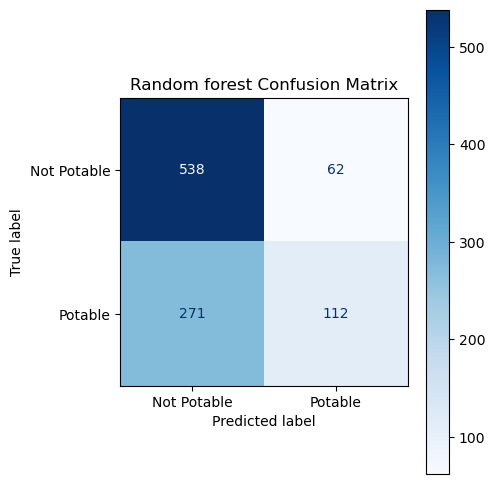

In [46]:
fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    display_labels=["Not Potable", "Potable"],
    cmap="Blues",
    ax=ax,
)
ax.set_title("Random forest Confusion Matrix")
plt.tight_layout()
plt.show()


<!-- BEGIN QUESTION -->

> **Q7:** Report the results of the confusion matrix. How many false positives, true positives, false negatives, and true negatives did your model predict? Interpret what each of those 4 results means in the context of the data.

False Positives (FP): 62 instances were predicted as potable but were not potable.
True Positives (TP): 112 instances were correctly predicted as potable and were actually potable.
False Negatives (FN): 271 instances were predicted as not potable but were actually potable.
True Negatives (TN): 538 instances were correctly predicted as not potable and were indeed not potable.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 11: Model Comparison

Create a table or bar chart comparing test accuracy across all three models.

In [47]:
# Table!
mdl_comparison = pd.DataFrame({
    "Model": ["Decision tree (unpruned)", "Decision tree (tuned)", "Random forest"],
    "Test Accuracy": [dt_unpruned_acc_test, acc_dt, acc_rf],
})
mdl_comparison

,Model,Test Accuracy
0,Decision tree (unpruned),0.580875
1,Decision tree (tuned),0.645982
2,Random forest,0.661241


> **Q8:** Which model achieved the highest test accuracy? Comparing the unpruned and tuned decision tree, how much did pruning improve accuracy? What does this tell you about overfitting in the unpruned tree?


The highest test accuracy came from the random forest model. Pruning improved the test accuracy greatly (~0.6), showing that less tree levels reduces overfitting and improves test accuracy. 

---

Run the cell below to receive credit for autograded questions. 

In [48]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!